# 锚框
:label:`sec_anchor`

目标检测算法通常会在输入图像中采样大量的区域，然后判断这些区域中是否包含我们感兴趣的目标，并调整区域边界从而更准确地预测目标的*真实边界框*（ground-truth bounding box）。
不同的模型使用的区域采样方法可能不同。
这里我们介绍其中的一种方法：以每个像素为中心，生成多个缩放比和宽高比（aspect ratio）不同的边界框。
这些边界框被称为*锚框*（anchor box）我们将在 :numref:`sec_ssd`中设计一个基于锚框的目标检测模型。

首先，让我们修改输出精度，以获得更简洁的输出。


In [ ]:
%matplotlib inline
import torch
from d2l import torch as d2l

torch.set_printoptions(2)  # 精简输出精度

## 生成多个锚框

假设输入图像的高度为$h$，宽度为$w$。
我们以图像的每个像素为中心生成不同形状的锚框：*缩放比*为$s\in (0, 1]$，*宽高比*为$r > 0$。
那么[**锚框的宽度和高度分别是$hs\sqrt{r}$和$hs/\sqrt{r}$。**]
请注意，当中心位置给定时，已知宽和高的锚框是确定的。

要生成多个不同形状的锚框，让我们设置许多缩放比（scale）取值$s_1,\ldots, s_n$和许多宽高比（aspect ratio）取值$r_1,\ldots, r_m$。
当使用这些比例和长宽比的所有组合以每个像素为中心时，输入图像将总共有$whnm$个锚框。
尽管这些锚框可能会覆盖所有真实边界框，但计算复杂性很容易过高。
在实践中，(**我们只考虑**)包含$s_1$或$r_1$的(**组合：**)

(**
$$(s_1, r_1), (s_1, r_2), \ldots, (s_1, r_m), (s_2, r_1), (s_3, r_1), \ldots, (s_n, r_1).$$
**)

也就是说，以同一像素为中心的锚框的数量是$n+m-1$。
对于整个输入图像，将共生成$wh(n+m-1)$个锚框。

上述生成锚框的方法在下面的`multibox_prior`函数中实现。
我们指定输入图像、尺寸列表和宽高比列表，然后此函数将返回所有的锚框。



### 1. 正向假设（代码的起点）
代码直接硬编码了归一化高度 $ h_{norm} $ 的计算公式，**不引入任何图像宽高比 $ W, H $ 的干扰**：
$$
h_{norm} = \frac{s}{\sqrt{r}}
$$
（这就是代码里 `h = size_tensor / torch.sqrt(ratio_tensor)` 的由来）

### 2. 物理空间约束（实际的宽高比）
我们要求锚框在**真实物理像素空间**里的宽高比必须严格等于 $ r $：
$$
\frac{W_{物理像素}}{H_{物理像素}} = r
$$

### 3. 反推归一化宽度（代码的执行）
- 物理高度：$ H_{物理} = h_{norm} \times H_{图像} = \frac{s}{\sqrt{r}} \times H $
- 为了满足比例 $ r $，物理宽度必须是：$ W_{物理} = H_{物理} \times r = \frac{s}{\sqrt{r}} \times H \times r = s \times \sqrt{r} \times H $
- 将这个物理宽度换算回**归一化坐标**（除以图像宽度 $ W $）：
$$
w_{norm} = \frac{W_{物理}}{W_{图像}} = \frac{s \times \sqrt{r} \times H}{W} = (s \times \sqrt{r}) \times \frac{H}{W}
$$

这最后一步得到的 $ (s \times \sqrt{r}) \times \frac{H}{W} $ 恰恰就是代码里的：
```python
w = (size_tensor * torch.sqrt(ratio_tensor)) * in_height / in_width
```

---

In [ ]:
#@save
def multibox_prior(data, sizes, ratios):
    """
    生成以每个像素为中心具有不同形状的锚框。

    参数:
        data: 输入特征图或图像，形状为 (batch_size, channels, height, width)
        sizes: 缩放比列表，如 [0.2, 0.5] 表示两个缩放尺度
        ratios: 宽高比列表，如 [1, 2, 0.5] 表示三种比例
    返回:
        output: 形状为 (1, height * width * boxes_per_pixel, 4) 的张量，
                每行是一个锚框的归一化坐标 (x_min, y_min, x_max, y_max)
    """
    # 获取图像的高度和宽度（像素数）
    in_height, in_width = data.shape[-2:]  # 例如 (600, 800)
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    # 每个像素要生成的锚框数量 = 尺寸数 + 比例数 - 1
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)      # 形状 (num_sizes,)
    ratio_tensor = torch.tensor(ratios, device=device)    # 形状 (num_ratios,)

    # ======================== 生成所有像素中心点 ========================
    # 偏移量：将锚点对准像素的中心（而不是左上角）
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height   # 归一化步长，将行索引映射到 [0,1]
    steps_w = 1.0 / in_width

    # center_h 形状: (in_height,)  e.g. [0.5/H, 1.5/H, ..., (H-0.5)/H]
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    # center_w 形状: (in_width,)
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w

    # 生成网格坐标矩阵，indexing='ij' 保证第一个输出对应行(高度)，第二个对应列(宽度)
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    # shift_y, shift_x 形状均为 (in_height, in_width)

    # 将网格拉平，得到所有像素中心点的 y 和 x 坐标
    shift_y = shift_y.reshape(-1)   # 形状 (in_height * in_width,)
    shift_x = shift_x.reshape(-1)   # 形状 (in_height * in_width,)

    # ======================== 生成锚框的宽高模板 ========================
    # 计算未经归一化（相对于图像宽高）的宽度和高度
    # 宽度需要额外乘以 in_height/in_width 来矫正图像宽高比，确保物理比例正确
    # w 和 h 的形状均为 (boxes_per_pixel,)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:]))) \
                   * in_height / in_width
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))

    # 生成每个锚框相对于中心点的偏移量（左上和右下）
    # 先组合 [-w, -h, w, h]，再除以 2 得到半宽半高
    # anchor_manipulations 形状: (boxes_per_pixel, 4)
    anchor_manipulations = torch.stack((-w, -h, w, h)).T / 2

    # 将偏移量模板复制到每个像素点，使每个像素都有一份完整的偏移模板
    # 复制次数 = 像素总数 (in_height * in_width)
    # 最终形状: (in_height * in_width * boxes_per_pixel, 4)
    anchor_manipulations = anchor_manipulations.repeat(in_height * in_width, 1)

    # ======================== 生成所有锚框的中心坐标 ========================
    # 将每个像素中心点包装成 [x, y, x, y]，用于后续直接加偏移量
    # 初始形状: (in_height * in_width, 4)
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1)

    # 为了与偏移量一一对应，需要将每个中心点重复 boxes_per_pixel 次
    # repeat_interleave 实现：每个中心点原地复制 boxes_per_pixel 份
    # 最终形状: (in_height * in_width * boxes_per_pixel, 4)
    out_grid = out_grid.repeat_interleave(boxes_per_pixel, dim=0)

    # ======================== 中心坐标 + 偏移 = 边界框坐标 ========================
    # 逐元素相加，得到所有锚框的 (x_min, y_min, x_max, y_max)
    output = out_grid + anchor_manipulations   # 形状同上

    # 添加批量维度，返回形状 (1, total_anchors, 4)
    return output.unsqueeze(0)

可以看到[**返回的锚框变量`Y`的形状**]是（批量大小，锚框的数量，4）。


In [ ]:
img = d2l.plt.imread('../img/catdog.jpg')
h, w = img.shape[:2]

print(h, w)
X = torch.rand(size=(1, 3, h, w))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

561 728


torch.Size([1, 2042040, 4])

将锚框变量`Y`的形状更改为(图像高度,图像宽度,以同一像素为中心的锚框的数量,4)后，我们可以获得以指定像素的位置为中心的所有锚框。
在接下来的内容中，我们[**访问以（250,250）为中心的第一个锚框**]。
它有四个元素：锚框左上角的$(x, y)$轴坐标和右下角的$(x, y)$轴坐标。
输出中两个轴的坐标各分别除以了图像的宽度和高度。


In [ ]:
boxes = Y[0].reshape(h, w, 5, 4)
boxes[250, 250, 0, :]

tensor([0.06, 0.07, 0.63, 0.82])

为了[**显示以图像中以某个像素为中心的所有锚框**]，定义下面的`show_bboxes`函数来在图像上绘制多个边界框。


In [ ]:
#@save
def show_bboxes(axes, bboxes, labels=None, colors=None):
    """
    在指定的 Matplotlib 坐标轴上绘制多个边界框，并可选添加标签。

    参数:
        axes: matplotlib.axes.Axes 对象，绘图的目标画布
        bboxes: 边界框列表，每个元素可以是：
                - PyTorch Tensor，形状 (4,)，顺序 [x_min, y_min, x_max, y_max]
                - NumPy 数组，形状 (4,)
                坐标可以是归一化的（0~1）或像素坐标，取决于 axes 当前的坐标系。
        labels: 可选，字符串或字符串列表，与 bboxes 一一对应的标签。
                如果为 None，则不显示标签。
        colors: 可选，颜色字符串或颜色列表，用于框和标签背景色。
                如果为 None，默认使用 ['b','g','r','m','c']（蓝绿红品红青）。
                颜色不够时自动循环。

    返回:
        None（直接修改传入的 axes 对象，无返回值）
    """
    # ---------- 内部辅助函数：将输入规范化为列表 ----------
    def _make_list(obj, default_values=None):
        """
        将 obj 转换为列表，便于统一遍历。
        如果 obj 是 None，返回 default_values（如果是 None 则返回 None）；
        如果 obj 不是列表或元组，将其包装为单元素列表；
        否则原样返回。
        """
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    # 规范化 labels 和 colors
    labels = _make_list(labels)           # 现在 labels 要么是列表，要么是 None
    colors = _make_list(colors, ['b', 'g', 'r', 'm', 'c'])  # 默认颜色列表

    # 遍历每个边界框
    for i, bbox in enumerate(bboxes):
        # 选择颜色（循环使用）
        color = colors[i % len(colors)]

        # 将 bbox 张量（可能带梯度）转为 NumPy 数组，并转换成 Matplotlib 的 Rectangle 对象
        # bbox.detach() 切断梯度（只用于绘图），.numpy() 转为 NumPy
        # d2l.bbox_to_rect 将 [x_min, y_min, x_max, y_max] 转为 (左上x, 左上y, 宽, 高)
        rect = d2l.bbox_to_rect(bbox.detach().numpy(), color)

        # 将矩形添加到坐标轴
        axes.add_patch(rect)

        # 如果有标签且索引有效，则在矩形左上角添加带背景的文字标签
        if labels and len(labels) > i:
            # 文字颜色根据背景色自动选择：如果背景是白色，文字用黑色，否则用白色
            text_color = 'k' if color == 'w' else 'w'

            # rect.xy 是矩形左下角坐标 (x_min, y_min)
            # 但因为在图像坐标系中 y 轴向下，所以文本实际上会出现在矩形左上角附近
            axes.text(
                rect.xy[0], rect.xy[1], labels[i],      # 文本位置 (x_min, y_min) 和内容
                va='center', ha='center',              # 垂直和水平居中（相对于指定点）
                fontsize=9,                            # 字体大小
                color=text_color,                      # 文字颜色（与背景形成对比）
                bbox=dict(facecolor=color, lw=0)       # 文本背景框：颜色同边框，无边框线
            )

正如从上面代码中所看到的，变量`boxes`中$x$轴和$y$轴的坐标值已分别除以图像的宽度和高度。
绘制锚框时，我们需要恢复它们原始的坐标值。
因此，在下面定义了变量`bbox_scale`。
现在可以绘制出图像中所有以(250,250)为中心的锚框了。
如下所示，缩放比为0.75且宽高比为1的蓝色锚框很好地围绕着图像中的狗。


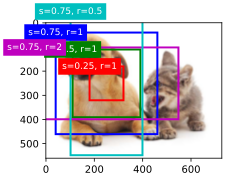

In [ ]:
d2l.set_figsize()
bbox_scale = torch.tensor((w, h, w, h))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

## [**交并比（IoU）**]

我们刚刚提到某个锚框“较好地”覆盖了图像中的狗。
如果已知目标的真实边界框，那么这里的“好”该如何如何量化呢？
直观地说，可以衡量锚框和真实边界框之间的相似性。
*杰卡德系数*（Jaccard）可以衡量两组之间的相似性。
给定集合$\mathcal{A}$和$\mathcal{B}$，他们的杰卡德系数是他们交集的大小除以他们并集的大小：

$$J(\mathcal{A},\mathcal{B}) = \frac{\left|\mathcal{A} \cap \mathcal{B}\right|}{\left| \mathcal{A} \cup \mathcal{B}\right|}.$$

事实上，我们可以将任何边界框的像素区域视为一组像素。通
过这种方式，我们可以通过其像素集的杰卡德系数来测量两个边界框的相似性。
对于两个边界框，它们的杰卡德系数通常称为*交并比*（intersection over union，IoU），即两个边界框相交面积与相并面积之比，如 :numref:`fig_iou`所示。
交并比的取值范围在0和1之间：0表示两个边界框无重合像素，1表示两个边界框完全重合。
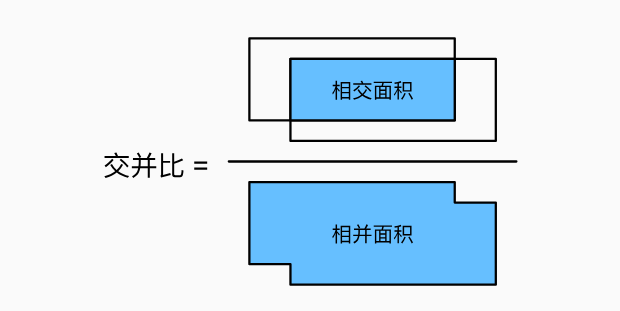  
![交并比是两个边界框相交面积与相并面积之比。]
:label:`fig_iou`

接下来部分将使用交并比来衡量锚框和真实边界框之间、以及不同锚框之间的相似度。
给定两个锚框或边界框的列表，以下`box_iou`函数将在这两个列表中计算它们成对的交并比。


当两个张量（Tensor）进行逐元素运算（如 torch.max, +, - 等）时，PyTorch 会从最后一个维度（右对齐）开始逐个对比它们的形状：  
    规则 1：如果两个张量的维数不同，维度少的那个张量会在前面（左侧）补 1，直到维数相同。  
    规则 2：在某个维度上，如果两个张量的大小相同，或者其中有一个的大小为 1，则该维度兼容。  
    规则 3：如果某个维度的大小为 1，PyTorch 会沿着该维度复制/拉伸（Expand）数据，使其大小与另一个张量在该维度的大小一致。  

In [ ]:

# @save
def box_iou(boxes1, boxes2):
    """计算两个锚框或边界框列表中成对的交并比 (IoU)

    参数格式：
    boxes1: 形状为 (N, 4) 的张量，每行为 [x1, y1, x2, y2]（左上角和右下角坐标）
    boxes2: 形状为 (M, 4) 的张量，每行为 [x1, y1, x2, y2]
    """

    # 1. 定义闭包函数计算框的面积：(x2 - x1) * (y2 - y1)
    # 输入形状: (K, 4) -> 返回形状: (K,)
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))

    # 2. 计算 boxes1 和 boxes2 中每个框各自的面积
    # areas1 形状: (N,)
    # areas2 形状: (M,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)


    # (0,0) 原点 -----------------------------------------> X 轴 (向右)
    #   |
    #   |      (x1_1, y1_1) [Box 1 左上]
    #   |         +-----------------------+
    #   |         | Box 1                 |
    #   |         |      (x1_2, y1_2) [Box 2 左上 = 相交区域左上 max]
    #   |         |         +-------------+-----------------+
    #   |         |         |#############|                 |
    #   |         |         |  重叠相交    |                 |
    #   |         |         |    区域      |                 |
    #   |         +---------+-------------+                 |
    #   |              (x2_1, y2_1) [Box 1 右下 = 相交区域右下 min]
    #   |                   |                               |
    #   |                   |                         Box 2 |
    #   |                   +-------------------------------+
    #   |                                              (x2_2, y2_2) [Box 2 右下]
    #   v
    # Y 轴 (向下)

    # 3. 计算相交区域（Intersection）的左上角坐标和右下角坐标
    # ------------------------------------------------------------------------
    # 形状变换解析：
    # boxes1[:, None, :2] 形状为 (N, 1, 2) —— 在第1维插入新轴，用于触发广播
    # boxes2[:, :2]       形状为 (M, 2)
    #
    # Y 轴 (向下)
    # 根据广播机制：
    # (N, 1, 2) 与 (M, 2) 进行 torch.max 比较时：
    # 维度自动对齐展开为 (N, M, 2)，计算出每对框相交部分的左上角坐标 (max_x1, max_y1)
    # 其实就是在每个 boxes1[i] 和 boxes2[j] 之间，取左上角坐标的最大值，得到相交区域的左上角
    # i,j索引的地方就是boix1中第 i 个框和 boxes2 中第 j 个框的交集左上角坐标
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2]) # (N, M, 2)

    # 同理，计算每对框相交部分的右下角坐标 (min_x2, min_y2)
    # boxes1[:, None, 2:] 形状: (N, 1, 2)
    # boxes2[:, 2:]       形状: (M, 2)
    # 比较后输出形状: (N, M, 2)
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:]) # (N, M, 2)

    # 4. 计算相交区域的宽度和高度
    # (inter_lowerrights - inter_upperlefts) 形状为 (N, M, 2)
    # .clamp(min=0) 用于处理无相交的情况：若右下角坐标小于左上角坐标，说明无交集，差值为负数，截断归零
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)     # (N, M, 2)

    # 5. 计算相交区域的面积 (Intersection Area)
    # inters[:, :, 0] 是相交宽, 形状 (N, M)
    # inters[:, :, 1] 是相交高, 形状 (N, M)
    # 元素逐位相乘后，得到的相交面积形状为: (N, M)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]                 # (N, M)

    # 6. 计算并集区域的面积 (Union Area)
    # ------------------------------------------------------------------------
    # 形状变换解析：
    # areas1[:, None] 形状为 (N, 1)
    # areas2          形状为 (M,)
    # inter_areas     形状为 (N, M)
    #
    # 根据广播机制：
    # (N, 1) + (M,) -> (N, M)，表示第 i 个 box1 的面积加上第 j 个 box2 的面积
    # 再减去重复计入的交集面积 inter_areas (N, M)
    # 最终的并集面积形状为: (N, M)
    union_areas = areas1[:, None] + areas2 - inter_areas             # (N, M)

    # 7. 计算交并比 (IoU = 相交面积 / 并集面积)
    # 逐元素相除，返回矩阵中位置 (i, j) 表示 boxes1[i] 和 boxes2[j] 的 IoU 值
    # 返回形状: (N, M)
    return inter_areas / union_areas

## 在训练数据中标注锚框
:label:`subsec_labeling-anchor-boxes`

在训练集中，我们将每个锚框视为一个训练样本。
为了训练目标检测模型，我们需要每个锚框的*类别*（class）和*偏移量*（offset）标签，其中前者是与锚框相关的对象的类别，后者是真实边界框相对于锚框的偏移量。
在预测时，我们为每个图像生成多个锚框，预测所有锚框的类别和偏移量，根据预测的偏移量调整它们的位置以获得预测的边界框，最后只输出符合特定条件的预测边界框。

目标检测训练集带有*真实边界框*的位置及其包围物体类别的标签。
要标记任何生成的锚框，我们可以参考分配到的最接近此锚框的真实边界框的位置和类别标签。
下文将介绍一个算法，它能够把最接近的真实边界框分配给锚框。

### [**将真实边界框分配给锚框**]

给定图像，假设锚框是$A_1, A_2, \ldots, A_{n_a}$，真实边界框是$B_1, B_2, \ldots, B_{n_b}$，其中$n_a \geq n_b$。
让我们定义一个矩阵$\mathbf{X} \in \mathbb{R}^{n_a \times n_b}$，其中第$i$行、第$j$列的元素$x_{ij}$是锚框$A_i$和真实边界框$B_j$的IoU。
该算法包含以下步骤。

1. 在矩阵$\mathbf{X}$中找到最大的元素，并将它的行索引和列索引分别表示为$i_1$和$j_1$。然后将真实边界框$B_{j_1}$分配给锚框$A_{i_1}$。这很直观，因为$A_{i_1}$和$B_{j_1}$是所有锚框和真实边界框配对中最相近的。在第一个分配完成后，丢弃矩阵中${i_1}^\mathrm{th}$行和${j_1}^\mathrm{th}$列中的所有元素。
1. 在矩阵$\mathbf{X}$中找到剩余元素中最大的元素，并将它的行索引和列索引分别表示为$i_2$和$j_2$。我们将真实边界框$B_{j_2}$分配给锚框$A_{i_2}$，并丢弃矩阵中${i_2}^\mathrm{th}$行和${j_2}^\mathrm{th}$列中的所有元素。
1. 此时，矩阵$\mathbf{X}$中两行和两列中的元素已被丢弃。我们继续，直到丢弃掉矩阵$\mathbf{X}$中$n_b$列中的所有元素。此时已经为这$n_b$个锚框各自分配了一个真实边界框。
1. 只遍历剩下的$n_a - n_b$个锚框。例如，给定任何锚框$A_i$，在矩阵$\mathbf{X}$的第$i^\mathrm{th}$行中找到与$A_i$的IoU最大的真实边界框$B_j$，只有当此IoU大于预定义的阈值时，才将$B_j$分配给$A_i$。

下面用一个具体的例子来说明上述算法。
如 :numref:`fig_anchor_label`（左）所示，假设矩阵$\mathbf{X}$中的最大值为$x_{23}$，我们将真实边界框$B_3$分配给锚框$A_2$。
然后，我们丢弃矩阵第2行和第3列中的所有元素，在剩余元素（阴影区域）中找到最大的$x_{71}$，然后将真实边界框$B_1$分配给锚框$A_7$。
接下来，如 :numref:`fig_anchor_label`（中）所示，丢弃矩阵第7行和第1列中的所有元素，在剩余元素（阴影区域）中找到最大的$x_{54}$，然后将真实边界框$B_4$分配给锚框$A_5$。
最后，如 :numref:`fig_anchor_label`（右）所示，丢弃矩阵第5行和第4列中的所有元素，在剩余元素（阴影区域）中找到最大的$x_{92}$，然后将真实边界框$B_2$分配给锚框$A_9$。
之后，我们只需要遍历剩余的锚框$A_1, A_3, A_4, A_6, A_8$，然后根据阈值确定是否为它们分配真实边界框。

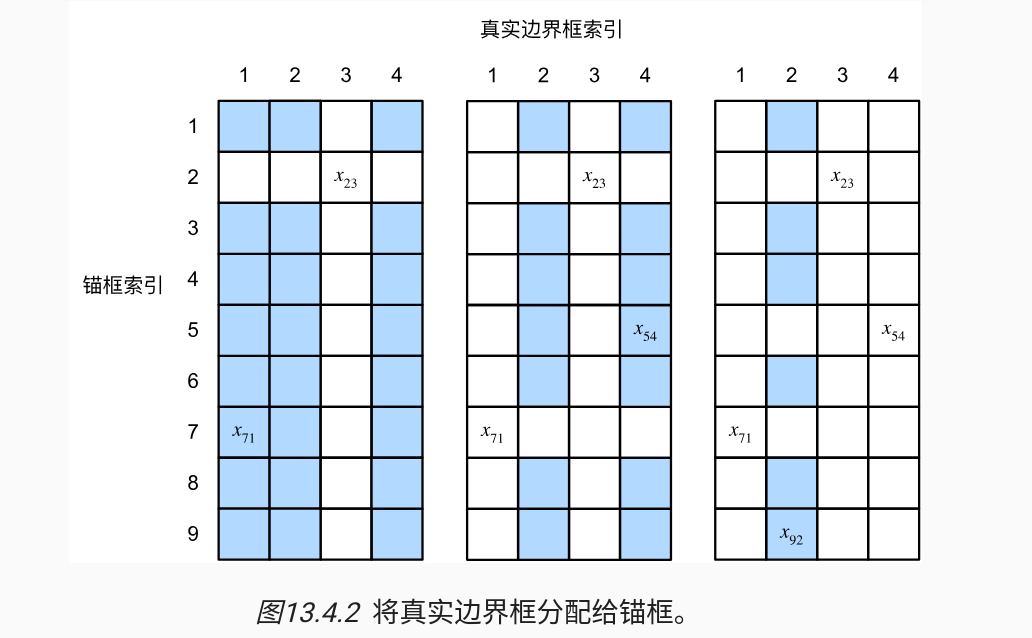

此算法在下面的`assign_anchor_to_bbox`函数中实现。



为了让你更系统、更清晰地梳理这段思路，这里为你整理并重构这段逻辑：

---

### 1. 阶段 A 的局限：只记“第一志愿”，形成“多对一”

* **对 Anchor 的限制**：每个 Anchor 极其“自私”，只看自己最大的那个 IoU，因此只匹配了它的**第一志愿（最大 IoU 的 GT）**。
* **对 GT 的现象**：可能会有多个 Anchor 的“第一志愿”都是同一个 GT（同一列出现多个最大值）。
* **映射表初始状态**：阶段 A 结束时，映射表 `anchors_bbox_map` 里**只记录了每个 Anchor 的第一志愿 GT**，完全没有记录任何次大值。

---

### 2. 阶段 B 的第一轮淘汰：状元录取，抹除行列

* **争夺战**：阶段 B 按照全局 IoU 从大到小的顺序，为每个 GT 挑选全场最完美的 Anchor（“状元”）。
* **行与列的抹除**：
* **抹除列（GT）**：该 GT 已经找到了全局最好的专属 Anchor，配对完成，之后不再参与后续匹配。
* **抹除行（Anchor）**：该 Anchor 已经被确定绑定给当前 GT，不能再给其他 GT 使用。


* **“落榜”Anchor 的命运**：那些在阶段 A 里“第一志愿”也是这个 GT、但 IoU 竞争没拼过最强 Anchor 的候选者们，**它们的第一志愿随着这一列被抹除而彻底作废**。

---

### 3. 阶段 B 的后续循环：“次大值逆袭”与动态调剂

* **触发逆袭**：上一轮的 GT 列被抹掉后，部分落榜 Anchor 的“第一志愿”没了，但它们的第二志愿（次大 IoU 对应的另一个 GT）在剩下的未分配矩阵中成为了新的全局最大值。
* **为什么映射表此前没记录**：因为阶段 A 的设计极简，只保留了单行最大值，根本没存次大值。
* **映射表覆写（覆盖）**：
1. 这个 Anchor 的第一志愿已经被其他更强的 Anchor 抢走（所在列已作废）。
2. 但它与另一个 GT（第二志愿）依然有极高的重叠度，且这个 GT 目前最需要它。
3. 于是阶段 B 将它分配给这个新的 GT，**并用这个“第二志愿 GT 的索引”直接覆盖掉映射表中先前记录的、已经作废的第一志愿索引**。

---


目标检测标签分配的核心“灵魂”！

“多对一（Multi-to-One）”可以，但“一对多（One-to-Multiple）”不行。  
一个anchor只能对一个真值，但是一个真值可以对多个anchor

核心是max_ious, indices = torch.max(jaccard, dim=1)这行代码

In [ ]:
# @save
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """将最接近的真实边界框分配给锚框

    参数：
    ground_truth: 真实边界框，形状为 (num_gt_boxes, 4)
    anchors: 锚框，形状为 (num_anchors, 4)
    device: 计算设备 (如 'cpu' 或 'cuda')
    iou_threshold: IoU 阈值，只有大于等于该阈值的锚框才会被赋予正样本标签
    
    返回：
    anchors_bbox_map: 形状为 (num_anchors,) 的张量，记录每个锚框分配给哪个真实框（索引值），
                      如果未分配（背景/负样本），则值为 -1
    """
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    
    # 1. 计算所有锚框和真实框之间的交并比矩阵 (IoU)
    # jaccard 形状为: (num_anchors, num_gt_boxes)
    # jaccard[i, j] 表示第 i 个锚框与第 j 个真实框的 IoU
    jaccard = box_iou(anchors, ground_truth)
    
    # 2. 初始化映射表，默认所有锚框都分配为 -1（即背景 / 负样本）
    # 形状: (num_anchors,)
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,device=device)
    
    # ------------------------------------------------------------------------
    # 阶段 A：初步筛选，按阈值将真实框分配给锚框
    # ------------------------------------------------------------------------
    # 找到每个锚框重叠度最大的真实框：
    # max_ious 形状为 (num_anchors,)，记录每个锚框的最大 IoU 值
    # indices 形状为 (num_anchors,)，记录对应的真实框索引 j
    max_ious, indices = torch.max(jaccard, dim=1)
    # 注意，这里的操作实际上可能出现多个anchor和同一个真值框的IOU都很大
    
    # 找出 IoU 满足阈值条件的锚框索引 (anc_i) ，返回数值为true的索引矩阵
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    # 对应的真实手工标注框索引 (box_j)
    box_j = indices[max_ious >= iou_threshold]
    
    # 将满足阈值的真实框索引写入映射表
    anchors_bbox_map[anc_i] = box_j

    # 就是说，anchor的数量一定是大于真值框的，所以，每个anchor，先找到与所有真值的最大IOU，然后再通过阈值来筛掉一部分没用的anchor

    # ------------------------------------------------------------------------
    # 阶段 B：保证每个 Ground Truth 框至少分配到一个最优的锚框（贪心算法）
    # ------------------------------------------------------------------------
    # 定义丢弃标志，将已匹配过的行/列清空用 -1 充当掩码
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    
    # 循环 num_gt_boxes 次，每次选出当前矩阵中最大的 IoU 匹配对
    for _ in range(num_gt_boxes):
        # # 找到全局最大 IoU 的扁平化索引 (Flat Index)
        max_idx = torch.argmax(jaccard)

        # 对于一个高为 $R$（num_anchors）、宽为 $C$（num_gt_boxes）的二维矩阵：$$\text{Flat Index} = \text{行索引} \times C + \text{列索引}$$
        # # 将扁平化索引还原为 2D 矩阵的列索引 (对应的真实框索引) 和行索引 (对应的锚框索引)
        # box_idx = (max_idx % num_gt_boxes).long()  # 所在的列
        # anc_idx = (max_idx / num_gt_boxes).long()  # 所在的行

        # 直接将一维索引还原为 (num_anchors, num_gt_boxes) 的二维坐标 (anc_idx, box_idx)
        anc_idx, box_idx = torch.unravel_index(max_idx, jaccard.shape)
        
        # 将最佳匹配赋予该锚框（此步骤会覆盖阶段 A 中可能存在的分配）
        # 因为对于同一个真值，只会给最大IOU的anchor
        anchors_bbox_map[anc_idx] = box_idx
        
        # 标记消除：将该真实框列和该锚框行全部置为 -1，避免后续重复选中
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
        
    return anchors_bbox_map


### 标记类别和偏移量

现在我们可以为每个锚框标记类别和偏移量了。
假设一个锚框$A$被分配了一个真实边界框$B$。
一方面，锚框$A$的类别将被标记为与$B$相同。
另一方面，锚框$A$的偏移量将根据$B$和$A$中心坐标的相对位置以及这两个框的相对大小进行标记。
鉴于数据集内不同的框的位置和大小不同，我们可以对那些相对位置和大小应用变换，使其获得分布更均匀且易于拟合的偏移量。
这里介绍一种常见的变换。
[**给定框$A$和$B$，中心坐标分别为$(x_a, y_a)$和$(x_b, y_b)$，宽度分别为$w_a$和$w_b$，高度分别为$h_a$和$h_b$，可以将$A$的偏移量标记为：

$$\left( \frac{ \frac{x_b - x_a}{w_a} - \mu_x }{\sigma_x},
\frac{ \frac{y_b - y_a}{h_a} - \mu_y }{\sigma_y},
\frac{ \log \frac{w_b}{w_a} - \mu_w }{\sigma_w},
\frac{ \log \frac{h_b}{h_a} - \mu_h }{\sigma_h}\right),$$
**]
其中常量的默认值为 $\mu_x = \mu_y = \mu_w = \mu_h = 0, \sigma_x=\sigma_y=0.1$ ， $\sigma_w=\sigma_h=0.2$。
这种转换在下面的 `offset_boxes` 函数中实现。



为了让你彻底看懂这个公式，我们把它拆解为“为什么需要变换”**和**“推导过程与各个项的物理意义”两个部分。

---

### 一、 为什么要设计这个变换？（核心动机）

如果直接让神经网络预测真实框的绝对坐标（比如预测 $x_b = 250, y_b = 300$），会遇到两个巨大痛点：

1. **失去尺度不变性（Scale Invariance）**：大图里的绝对误差可能是几十像素，小图里可能只有几个像素。如果直接用绝对坐标，神经网络对不同尺度的目标非常敏感。
2. **缺乏约束（可能预测出负数的宽高）**：如果让网络直接预测宽度 $w_b$，网络输出负数时在物理上毫无意义。

因此，**我们不预测绝对坐标，而是预测锚框 $A$ 调整到真实框 $B$ 所需要的“相对变动量（偏移量）”**。

---

### 二、 公式逐项拆解与推导

公式最终要输出的是一个四维向量 $(\Delta x, \Delta y, \Delta w, \Delta h)$，分别对应**中心点 X 轴位移、中心点 Y 轴位移、宽度缩放比例、高度缩放比例**。

#### 1. 中心点偏移量 $(\Delta x, \Delta y)$ 的推导

我们希望知道：**真实框的中心 $(x_b, y_b)$ 距离锚框中心 $(x_a, y_a)$ 偏了多少？**

* **第一步（计算绝对偏差）**：$x_b - x_a$
* **第二步（相对化/归一化）**：直接相减还会受框的大小影响，所以除以锚框自身的宽度 $w_a$：

$$\text{相对位移} = \frac{x_b - x_a}{w_a}$$



这样算出来的数值含义是：**“中心点移动了多少个锚框宽度的距离”**。同理，$Y$ 轴上就是 $\frac{y_b - y_a}{h_a}$。

---

#### 2. 宽高缩放量 $(\Delta w, \Delta h)$ 的推导

我们希望知道：**锚框的宽高 $(w_a, h_a)$ 需要放大或缩小多少倍才能变成真实框的宽高 $(w_b, h_b)$？**

* **第一步（计算比例）**：$\frac{w_b}{w_a}$（如果大 2 倍就是 2，小一半就是 0.5）。
* **第二步（取自然对数 $\log$）**：为什么不直接用比例，非要取 $\log$？
* **保证预测框宽高恒正**：比例 $\frac{w_b}{w_a} \in (0, +\infty)$。取自然对数后，$\log\left(\frac{w_b}{w_a}\right) \in (-\infty, +\infty)$。
* **优势**：神经网络的线性输出层范围就是 $(-\infty, +\infty)$。无论网络预测出多么小的负数（比如 $-10$），我们解码时做一次指数还原 $e^{-10} \approx 0.000045$，**还原出的宽度也永远是大于 0 的正数，绝不会崩盘**！



---

#### 3. 均值 $\mu$ 与标准差 $\sigma$（标准化/放缩因子）

公式中的 $\mu$ 和 $\sigma$ 对应的是标准分数（Z-Score Normalization）思想：

$$\text{最终偏移量} = \frac{\text{原始变换量} - \mu}{\sigma}$$

* **$\mu_x = \mu_y = \mu_w = \mu_h = 0$（均值）**：
减去 0 代表假设偏差的均值在 0 附近。
* **$\sigma_x = \sigma_y = 0.1, \sigma_w = \sigma_h = 0.2$（标准差/放缩因子）**：
* 注意：除以 $0.1$ 等价于**乘以 10**，除以 $0.2$ 等价于**乘以 5**！
* **为什么要乘以 10 和 5？**
通常，锚框和真实框重叠度已经挺高了，计算出来的原始 $\frac{x_b - x_a}{w_a}$ 数值往往非常小（比如 $0.01$ 到 $0.05$ 之间）。
在神经网络中，如果分类 Loss 是 $1.0$ 数量级，而回归 Loss 是 $0.001$ 数量级，回归分支的梯度就会被分类分支掩盖掉。
**通过除以 $\sigma$（即放大 5~10 倍），把回归偏移量的数值强制拉升到接近 1 的数量级，让回归 Loss 和分类 Loss 能够平起平坐地训练！**

---

### 💡 总结

这个公式的本质就是三句话：

1. **中心点相减除以宽高** $\rightarrow$ 消除尺寸影响，做相对位移；
2. **宽高相除取 log** $\rightarrow$ 保证解码后的预测框宽高永远不为负数；
3. **除以 $\sigma$ (乘 10 / 乘 5)** $\rightarrow$ 放大数值，平衡训练时的 Loss 梯度。

In [ ]:
#@save
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """
    计算锚框 (Anchors) 相对于其分配到的真实框 (Ground Truth) 的坐标编码偏移量。
    
    【核心目的】：
    神经网络的回归分支并不直接预测边界框的绝对坐标，而是预测这个“相对偏移量”。
    该函数的作用就是生成模型训练时计算回归损失 (Regression Loss) 所需要的【标准答案/Target】。

    输入（Inputs）：
    -------------------------------------------------------------------------------------
    anchors:     [num_anchors, 4] -> 形状为 [N, 4] 的 Tensor
                 所有生成锚框的绝对坐标，格式为角点格式 [xmin, ymin, xmax, ymax]
                 
    assigned_bb: [num_anchors, 4] -> 形状为 [N, 4] 的 Tensor
                 与这 N 个锚框一一对应的真实框坐标，格式同样为角点格式 [xmin, ymin, xmax, ymax]
                 (注：此 Tensor 已根据标签分配结果扩充对齐到 N 行)
                 
    eps:         float, 默认 1e-6
                 极小值平滑项，防止计算对数 log(0) 时导致数值溢出 (NaN / -Inf)

    输出（Outputs）：
    -------------------------------------------------------------------------------------
    offset:      [num_anchors, 4] -> 形状为 [N, 4] 的 Tensor
                 每个锚框的编码偏移量目标 [\Delta x, \Delta y, \Delta w, \Delta h]
    """
    # ===================================================================================
    # 1. 坐标系转换：角点格式 [xmin, ymin, xmax, ymax] -> 中心点格式 [x_center, y_center, w, h]
    # ===================================================================================
    # c_anc 形状: [num_anchors, 4] -> 前 2 列为中心点 (x_a, y_a)，后 2 列为宽高 (w_a, h_a)
    c_anc = d2l.box_corner_to_center(anchors)
    
    # c_assigned_bb 形状: [num_anchors, 4] -> 前 2 列为中心点 (x_g, y_g)，后 2 列为宽高 (w_g, h_g)
    c_assigned_bb = d2l.box_corner_to_center(assigned_bb)

    # ===================================================================================
    # 2. 计算中心点偏移量 (\Delta x, \Delta y)
    # ===================================================================================
    # 物理意义: 计算真实框中心相对于锚框中心的相对偏移距离，并除以锚框自身的宽高进行归一化
    # 数学公式: \Delta x = 10 * (x_g - x_a) / w_a,  \Delta y = 10 * (y_g - y_a) / h_a
    # 乘以 10 (放缩因子): 放大通常较小的相对位移值，提高数值稳定性，平衡回归 Loss 梯度
    # offset_xy 形状: [num_anchors, 2]
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]

    # ===================================================================================
    # 3. 计算宽高对数缩放量 (\Delta w, \Delta h)
    # ===================================================================================
    # 物理意义: 计算真实框与锚框的宽高比例，并取自然对数 (log)
    # 数学公式: \Delta w = 5 * ln(eps + w_g / w_a),  \Delta h = 5 * ln(eps + h_g / h_a)
    # 取 log 的好处: 映射到 (-\infty, +\infty)，使得网络预测值解码还原时永远不会产生负数宽高
    # 乘以 5 (放缩因子): 放大 log 后的较小数值，平衡 Loss 数量级
    # offset_wh 形状: [num_anchors, 2]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])

    # ===================================================================================
    # 4. 拼接组合偏移量 [N, 2] + [N, 2] -> [N, 4]
    # ===================================================================================
    # 将 xy 偏移与 wh 偏移按列方向 (axis=1) 拼接
    # offset 形状: [num_anchors, 4]
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    
    return offset

如果一个锚框没有被分配真实边界框，我们只需将锚框的类别标记为*背景*（background）。
背景类别的锚框通常被称为*负类*锚框，其余的被称为*正类*锚框。
我们使用真实边界框（`labels`参数）实现以下`multibox_target`函数，来[**标记锚框的类别和偏移量**]（`anchors`参数）。
此函数将背景类别的索引设置为零，然后将新类别的整数索引递增一。


语法现象：维度保持（Keep Dimensions）规则：  
用什么形状的索引 Tensor 去索引，返回的结果就会保持什么样的形状。  
如果你用 一维向量 [K] 去索引一维 Tensor $\rightarrow$ 返回 [K]  
如果你用 二维矩阵 [K, 1] 去索引一维 Tensor $\rightarrow$ 返回 [K, 1]  

高级索引的“维度替换”公式  
在 PyTorch 中，当你用一个 Tensor （如 indices_true）去索引另一个 Tensor（如 assigned_bb）的某一个维度（这里是第 0 维）时，规则如下：  
被索引掉的那一维（第 0 维），其大小会被索引 Tensor 本身的 Shape 完整替换掉；而没有被索引的维度（第 1 维）则原封不动地保留在最后。  
公式推导如下：  
$$\begin{aligned} \text{原张量形状} &: (\mathbf{num\_anchors}, \, 4) \\ \text{索引 Tensor 形状} &: (\mathbf{num\_pos, \, 1}) \\ \text{索引动作} &: \text{用 } [num\_pos, 1] \text{ 去索引 } num\_anchors \text{ 这一维} \\ \text{结果形状} &: \underbrace{(num\_pos, \, 1)}_{\text{继承了索引的 Shape}} + \underbrace{(4)}_{\text{保留未索引的第 1 维}} = \mathbf{(num\_pos, \, 1, \, 4)} \end{aligned}$$

在目标检测中，模型不仅要识别出具体的物体类别（如猫、狗、车），还要识别出哪些区域是“背景”（没有目标）。  
原始标注（0-indexed）：  
 在数据集（如 COCO、VOC）中，物体的类别通常是从 0 开始编号的：  
 $$\text{猫} = 0, \quad \text{狗} = 1, \quad \text{车} = 2$$
加上 + 1 偏移后：  
 代码把所有真实物体的类别 ID 都往后挪了一位：  
 $$\text{背景 (Background)} = 0 \quad (\text{留给非正样本/背景锚框})$$
 $$\text{猫} = 1$$
 $$\text{狗} = 2$$
 $$\text{车} = 3$$
这样处理后，0 就被空出来专门表示“背景”，从而方便后续将正样本和负样本（背景）组合在一起进行统一的分类 Loss 计算。

In [ ]:
#@save
def multibox_target(anchors, labels):
    """
    使用真实边界框（Ground Truth Boxes）为锚框（Anchors）标记类别标签和回归偏移量目标。
    
    【核心目的】：
    在训练阶段，针对 Batch 中的每张图片，将生成的锚框与真实的物体框进行匹配。
    生成神经网络训练时需要的 3 个监督信号：
    1. bbox_offset:  正样本锚框相对于真实框的【目标偏移量】
    2. bbox_mask:    过滤背景框的【掩码向量】（正样本为 1，负样本为 0）
    3. class_labels: 锚框的【分类标签】（0 为背景，1~C 为具体类别）

    输入（Inputs）：
    -------------------------------------------------------------------------------------
    anchors: [1, num_anchors, 4] 或 [num_anchors, 4] -> Tensor (float32)
             生成的所有锚框的绝对坐标，格式为 [xmin, ymin, xmax, ymax]
             
    labels:  [batch_size, num_gt_per_image, 5] -> Tensor (float32)
             Batch 中每张图的真实框数据。
             最后一个维度的 5 个值为：[class_id, xmin, ymin, xmax, ymax]
             (若每张图 GT 数量不同，通常用 -1 进行填充对齐)

    输出（Outputs）：
    -------------------------------------------------------------------------------------
    返回一个三元组 (bbox_offset, bbox_mask, class_labels):
    - bbox_offset:  [batch_size, num_anchors * 4] -> 展平后的回归目标 (Target Offsets)
    - bbox_mask:    [batch_size, num_anchors * 4] -> 掩码，用于在 Loss 计算中屏蔽背景框
    - class_labels: [batch_size, num_anchors]     -> 每个锚框的类别标签（0 为背景）
    """
    # 1. 获取 Batch 大小，并将 anchors 解包为 2D 形状 [num_anchors, 4]
    # 全图（或全 Batch）共享同一套生成的锚框机制
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    
    # 用于收集 Batch 中每张图片的处理结果列表
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]

    # ===================================================================================
    # 2. 逐图循环遍历（按 Batch 中的每张图片独立进行标签匹配）
    # ===================================================================================
    for i in range(batch_size):
        label = labels[i, :, :]  # 取出第 i 张图片的真实标注，形状: [num_gt, 5]

        # -------------------------------------------------------------------------------
        # 步骤 A：正负样本匹配（基于 IoU 算法）
        # -------------------------------------------------------------------------------
        # label[:, 1:] 取出所有 GT 框的坐标 [num_gt, 4]
        # assign_anchor_to_bbox 计算每个锚框与哪个 GT 框重叠度高，并进行匹配
        # anchors_bbox_map 形状: [num_anchors]
        # 值为正整数 k 表示分配给第 k 个 GT 框；值为 -1 表示为背景/负样本
        anchors_bbox_map = assign_anchor_to_bbox(label[:, 1:], anchors, device)

        # -------------------------------------------------------------------------------
        # 步骤 B：构建掩码向量 (bbox_mask)
        # -------------------------------------------------------------------------------
        # (anchors_bbox_map >= 0) 产生布尔向量 -> .float() 转为 1.0(正样本) 和 0.0(负样本)
        # .unsqueeze(-1) 扩展维度变为 [num_anchors, 1]
        # .repeat(1, 4) 复制 4 次变 [num_anchors, 4]（因为每个锚框有 4 个坐标分量）
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(1, 4)

        # -------------------------------------------------------------------------------
        # 步骤 C：初始化当前图片的类别标签和 GT 坐标存储容器
        # -------------------------------------------------------------------------------
        # class_labels 初始化全为 0（默认所有锚框都是背景）
        class_labels = torch.zeros(num_anchors, dtype=torch.long, device=device)
        
        # assigned_bb 初始化全 0 的 [num_anchors, 4]，用来存与每个锚框匹配的 GT 坐标
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)

        # -------------------------------------------------------------------------------
        # 步骤 D：提取正样本索引，并填入真实的类别和坐标
        # -------------------------------------------------------------------------------
        # torch.nonzero(input) 的功能是：返回输入 Tensor 中所有非零（或 True）元素的【坐标索引（Index）】。
        # 它的返回值是一个 2D Tensor，形状为：[非零元素的数量, 原 Tensor 的维度]。
        # 传入 $N$ 阶张量，返回值是一个 2D Tensor，形状为[K, N]，N上的值表示的是每个维度上的索引

        # 获取所有非背景锚框（正样本）的索引位置，形状: [num_pos_anchors, 1]
        indices_true = torch.nonzero(anchors_bbox_map >= 0)

        
        # 取出正样本锚框对应的 GT 框的索引 ID，形状是(num_pos_anchors,1)
        bb_idx = anchors_bbox_map[indices_true]

        # 对于一个张量，如果索引是矩阵或者高阶张量，那么不同位置的索引会先广播，然后配对进行索引，最终输出的形状是广播之后的形状
        # 标注类别：加 1 是因为在目标检测中，类别 0 被保留用作表示“背景 (Background)”
        # 原始数据集类别 0 对应新标签 1，原类别 1 对应新标签 2，以此类推
        # label[bb_idx, 0]，索引是(num_pos_anchors,1)+0广播，最终输出形状就是(num_pos_anchors,1)，每个位置的索引就是对应的bb_idx的i,j和0的组合索引
        class_labels[indices_true] = label[bb_idx, 0].long() + 1  #原地修改

        # 当 PyTorch 遇到 [ Tensor 矩阵索引, 切片索引 ] 这种组合时，它采用的是 “维度拼接法”：最终形状 = Tensor 索引自身的 Shape + 切片切出来的长度
        # 填入匹配的真实框坐标到 assigned_bb 对应位置（背景行保留全 0），返回的形状是(num_pos_anchors,1，4)
        assigned_bb[indices_true] = label[bb_idx, 1:]  
        #(num_pos_anchors,1，4)=(num_pos_anchors,1，4)，原地修改assigned_bb，它依然是一个二阶张量

        # -------------------------------------------------------------------------------
        # 步骤 E：偏移量编码与 Mask 清理
        # -------------------------------------------------------------------------------
        # 调用 offset_boxes 函数，计算 [num_anchors, 4] 理论编码偏移量
        # 乘以 bbox_mask 的作用：将负样本（背景）计算出的无意义偏移量【强行清零】
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask

        # 展平为 1D 向量并收集：
        # offset.reshape(-1)    形状: [num_anchors * 4]
        # bbox_mask.reshape(-1) 形状: [num_anchors * 4]
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)

    # ===================================================================================
    # 3. Batch 维度堆叠与最终输出
    # ===================================================================================
    # 将列表转换为带 batch_size 维度的 Tensor
    bbox_offset = torch.stack(batch_offset)       # 形状: [batch_size, num_anchors * 4]
    bbox_mask = torch.stack(batch_mask)           # 形状: [batch_size, num_anchors * 4]
    class_labels = torch.stack(batch_class_labels) # 形状: [batch_size, num_anchors]

    return (bbox_offset, bbox_mask, class_labels)

### 一个例子

下面通过一个具体的例子来说明锚框标签。
我们已经为加载图像中的狗和猫定义了真实边界框，其中第一个元素是类别（0代表狗，1代表猫），其余四个元素是左上角和右下角的$(x, y)$轴坐标（范围介于0和1之间）。
我们还构建了五个锚框，用左上角和右下角的坐标进行标记：$A_0, \ldots, A_4$（索引从0开始）。
然后我们[**在图像中绘制这些真实边界框和锚框**]。


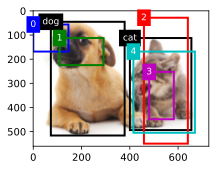

In [ ]:
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                         [1, 0.55, 0.2, 0.9, 0.88]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.15, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])

fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4']);

使用上面定义的`multibox_target`函数，我们可以[**根据狗和猫的真实边界框，标注这些锚框的分类和偏移量**]。
在这个例子中，背景、狗和猫的类索引分别为0、1和2。
下面我们为锚框和真实边界框样本添加一个维度。


In [ ]:
labels = multibox_target(anchors.unsqueeze(dim=0),
                         ground_truth.unsqueeze(dim=0))

返回的结果中有三个元素，都是张量格式。第三个元素包含标记的输入锚框的类别。

让我们根据图像中的锚框和真实边界框的位置来分析下面返回的类别标签。
首先，在所有的锚框和真实边界框配对中，锚框$A_4$与猫的真实边界框的IoU是最大的。
因此，$A_4$的类别被标记为猫。
去除包含$A_4$或猫的真实边界框的配对，在剩下的配对中，锚框$A_1$和狗的真实边界框有最大的IoU。
因此，$A_1$的类别被标记为狗。
接下来，我们需要遍历剩下的三个未标记的锚框：$A_0$、$A_2$和$A_3$。
对于$A_0$，与其拥有最大IoU的真实边界框的类别是狗，但IoU低于预定义的阈值（0.5），因此该类别被标记为背景；
对于$A_2$，与其拥有最大IoU的真实边界框的类别是猫，IoU超过阈值，所以类别被标记为猫；
对于$A_3$，与其拥有最大IoU的真实边界框的类别是猫，但值低于阈值，因此该类别被标记为背景。


In [ ]:
labels[2]

tensor([[0, 1, 2, 0, 2]])

返回的第二个元素是掩码（mask）变量，形状为（批量大小，锚框数的四倍）。
掩码变量中的元素与每个锚框的4个偏移量一一对应。
由于我们不关心对背景的检测，负类的偏移量不应影响目标函数。
通过元素乘法，掩码变量中的零将在计算目标函数之前过滤掉负类偏移量。


In [ ]:
labels[1]

tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
         1., 1.]])

返回的第一个元素包含了为每个锚框标记的四个偏移值。
请注意，负类锚框的偏移量被标记为零。


In [ ]:
labels[0]

tensor([[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00,  1.40e+00,  1.00e+01,
          2.59e+00,  7.18e+00, -1.20e+00,  2.69e-01,  1.68e+00, -1.57e+00,
         -0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00, -5.71e-01, -1.00e+00,
          4.17e-06,  6.26e-01]])

In [ ]:

def get_training_targets(ground_truth_labels, ground_truth_boxes, anchors, iou_threshold=0.5):
    """
    不使用 anchors_bbox_map 数组，直接基于矩阵向量化运算生成训练所需的类别标签与目标框坐标。

    参数：
    -------------------------------------------------------------------------------------
    ground_truth_labels: [num_gt_boxes] 
                         每个真实框的类别标签 (例如: [1, 2] 代表类别 1 和 2，0 通常保留给背景)
    ground_truth_boxes:  [num_gt_boxes, 4] 
                         每个真实框的坐标 (xmin, ymin, xmax, ymax)
    anchors:             [num_anchors, 4] 
                         所有生成锚框的坐标 (xmin, ymin, xmax, ymax)
    iou_threshold:       float
                         判断锚框是否为正样本的 IoU 阈值 (默认 0.5)

    返回：
    -------------------------------------------------------------------------------------
    class_labels:        [num_anchors] 
                         所有锚框最终对应的类别标签 (正样本为对应类别 1, 2..., 负样本/背景为 0)
    matched_gt_boxes:    [num_anchors, 4] 
                         每个锚框被分配到的真实框坐标 (无论正负样本均有一份参考 GT 坐标，后续配合 pos_mask 提取)
    pos_mask:            [num_anchors] 
                         布尔掩码 (bool)，True 表示该锚框是正样本，False 表示为负样本(背景)
    """
    num_anchors = anchors.shape[0]  # N: 锚框数量
    num_gt_boxes = ground_truth_boxes.shape[0]  # M: 真实框(GT)数量

    # ===================================================================================
    # 0. 计算交并比矩阵 (IoU Matrix)
    # ===================================================================================
    # jaccard 形状: [num_anchors, num_gt_boxes] -> 即 [N, M]
    # jaccard[i, j] 表示第 i 个锚框与第 j 个真实框之间的 IoU 数值
    jaccard = box_iou(anchors, ground_truth_boxes)

    # ===================================================================================
    # 1. 阶段 A：按行求最大值（以 Anchor 为主导，保证一个 Anchor 只选一个最佳 GT）
    # ===================================================================================
    # jaccard.max(dim=1) 沿列方向（即遍历 M 个 GT）找最大值：
    # - max_ious:        [num_anchors] -> 形状 [N]，记录每个锚框与所有 GT 的最大 IoU 值
    # - max_gt_indices:  [num_anchors] -> 形状 [N]，记录每个锚框获得最大 IoU 时对应的 GT 索引 (0 ~ M-1)
    max_ious, max_gt_indices = jaccard.max(dim=1)

    # max_gt_indices保证了每个anchor一定有的一个真值框

    # ===================================================================================
    # 2. 阶段 B：按列求最大值（以 GT 为主导，贪心保底机制，保证每个 GT 都能分配到 Anchor）
    # ===================================================================================
    # jaccard.max(dim=0) 沿行方向（即遍历 N 个 Anchor）找最大值：
    # - _:                       [num_gt_boxes] -> 每个 GT 获得的最大 IoU 值 (这里不需要用到)
    # - max_anchor_indices_for_gt: [num_gt_boxes] -> 形状 [M]，记录每个 GT 匹配到的全局最强 Anchor 索引 (0 ~ N-1)
    _, max_anchor_indices_for_gt = jaccard.max(dim=0)

    # max_anchor_indices_for_gt保证了每个真值框，一定有一个最大值的anchor

    # --- 构建正样本掩码 (Positive Mask) ---
    # pos_mask 形状: [num_anchors] -> 形状 [N] 的布尔向量
    # 步骤 2.1: 满足阈值条件的设为 True (例如 IoU >= 0.5)
    pos_mask = max_ious >= iou_threshold

    # 步骤 2.2: 强行将阶段 B 选出的 M 个保底 Anchor 的位置也置为 True
    # (即使某个 GT 对应的最大 IoU 小于 0.5，其专属的 Anchor 也会被强行设为正样本，防止目标漏检)
    pos_mask[max_anchor_indices_for_gt] = True

    # ===================================================================================
    # 3. 构建分类训练标签 (Class Targets)
    # ===================================================================================
    # 利用高级索引，直接根据每个 Anchor 锁定的 GT 索引提取对应类别
    # ground_truth_labels 形状: [num_gt_boxes]
    # max_gt_indices       形状: [num_anchors]
    # assigned_labels      形状: [num_anchors] -> 记录每个 Anchor 如果作为正样本时，应该预测的类别编号
    assigned_labels = ground_truth_labels[max_gt_indices]

    # 根据 pos_mask (num_anchors,)决定最终类别：
    # - 若 pos_mask[i] 为 True  -> 保留 assigned_labels[i] (真实类别 1, 2, ...)
    # - 若 pos_mask[i] 为 False -> 强制替换为 0 (背景类别)
    # class_labels 形状: [num_anchors]
    class_labels = torch.where(pos_mask, assigned_labels, torch.tensor(0, device=anchors.device))

    # ===================================================================================
    # 4. 构建回归坐标目标 (Bounding Box Targets)
    # ===================================================================================
    # ground_truth_boxes 形状: [num_gt_boxes, 4]
    # max_gt_indices     形状: [num_anchors]
    # matched_gt_boxes   形状: [num_anchors, 4]
    # 物理意义: 将每个 Anchor 匹配到的 GT 坐标扩充对齐到 [num_anchors, 4]。
    # 后续计算回归 Loss 时，只需要用 `anchors[pos_mask]` 和 `matched_gt_boxes[pos_mask]` 即可轻松计算偏移量！
    matched_gt_boxes = ground_truth_boxes[max_gt_indices]

    return class_labels, matched_gt_boxes, pos_mask

## 使用非极大值抑制预测边界框
:label:`subsec_predicting-bounding-boxes-nms`

在预测时，我们先为图像生成多个锚框，再为这些锚框一一预测类别和偏移量。
一个*预测好的边界框*则根据其中某个带有预测偏移量的锚框而生成。
下面我们实现了`offset_inverse`函数，该函数将锚框和偏移量预测作为输入，并[**应用逆偏移变换来返回预测的边界框坐标**]。


In [ ]:
#@save
def offset_inverse(anchors, offset_preds):
    """根据带有预测偏移量的锚框来预测边界框"""
    anc = d2l.box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = d2l.box_center_to_corner(pred_bbox)
    return predicted_bbox

当有许多锚框时，可能会输出许多相似的具有明显重叠的预测边界框，都围绕着同一目标。
为了简化输出，我们可以使用*非极大值抑制*（non-maximum suppression，NMS）合并属于同一目标的类似的预测边界框。

以下是非极大值抑制的工作原理。
对于一个预测边界框$B$，目标检测模型会计算每个类别的预测概率。
假设最大的预测概率为$p$，则该概率所对应的类别$B$即为预测的类别。
具体来说，我们将$p$称为预测边界框$B$的*置信度*（confidence）。
在同一张图像中，所有预测的非背景边界框都按置信度降序排序，以生成列表$L$。然后我们通过以下步骤操作排序列表$L$。

1. 从$L$中选取置信度最高的预测边界框$B_1$作为基准，然后将所有与$B_1$的IoU超过预定阈值$\epsilon$的非基准预测边界框从$L$中移除。这时，$L$保留了置信度最高的预测边界框，去除了与其太过相似的其他预测边界框。简而言之，那些具有*非极大值*置信度的边界框被*抑制*了。
1. 从$L$中选取置信度第二高的预测边界框$B_2$作为又一个基准，然后将所有与$B_2$的IoU大于$\epsilon$的非基准预测边界框从$L$中移除。
1. 重复上述过程，直到$L$中的所有预测边界框都曾被用作基准。此时，$L$中任意一对预测边界框的IoU都小于阈值$\epsilon$；因此，没有一对边界框过于相似。
1. 输出列表$L$中的所有预测边界框。

[**以下`nms`函数按降序对置信度进行排序并返回其索引**]。


In [ ]:
#@save
def nms(boxes, scores, iou_threshold):
    """对预测边界框的置信度进行排序"""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # 保留预测边界框的指标
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

我们定义以下`multibox_detection`函数来[**将非极大值抑制应用于预测边界框**]。
这里的实现有点复杂，请不要担心。我们将在实现之后，马上用一个具体的例子来展示它是如何工作的。


In [ ]:
#@save
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """使用非极大值抑制来预测边界框"""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)

        # 找到所有的non_keep索引，并将类设置为背景
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # pos_threshold是一个用于非背景预测的阈值
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

现在让我们[**将上述算法应用到一个带有四个锚框的具体示例中**]。
为简单起见，我们假设预测的偏移量都是零，这意味着预测的边界框即是锚框。
对于背景、狗和猫其中的每个类，我们还定义了它的预测概率。


In [ ]:
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.92], [0.08, 0.2, 0.56, 0.95],
                      [0.15, 0.3, 0.62, 0.91], [0.55, 0.2, 0.9, 0.88]])
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,  # 背景的预测概率
                      [0.9, 0.8, 0.7, 0.1],  # 狗的预测概率
                      [0.1, 0.2, 0.3, 0.9]])  # 猫的预测概率

我们可以[**在图像上绘制这些预测边界框和置信度**]。


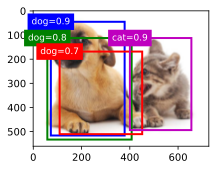

In [ ]:
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, anchors * bbox_scale,
            ['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

现在我们可以调用`multibox_detection`函数来执行非极大值抑制，其中阈值设置为0.5。
请注意，我们在示例的张量输入中添加了维度。

我们可以看到[**返回结果的形状是（批量大小，锚框的数量，6）**]。
最内层维度中的六个元素提供了同一预测边界框的输出信息。
第一个元素是预测的类索引，从0开始（0代表狗，1代表猫），值-1表示背景或在非极大值抑制中被移除了。
第二个元素是预测的边界框的置信度。
其余四个元素分别是预测边界框左上角和右下角的$(x, y)$轴坐标（范围介于0和1之间）。


In [ ]:
output = multibox_detection(cls_probs.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
output

tensor([[[ 0.00,  0.90,  0.10,  0.08,  0.52,  0.92],
         [ 1.00,  0.90,  0.55,  0.20,  0.90,  0.88],
         [-1.00,  0.80,  0.08,  0.20,  0.56,  0.95],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]])

删除-1类别（背景）的预测边界框后，我们可以[**输出由非极大值抑制保存的最终预测边界框**]。


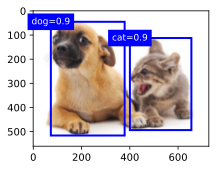

In [ ]:
fig = d2l.plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label)

实践中，在执行非极大值抑制前，我们甚至可以将置信度较低的预测边界框移除，从而减少此算法中的计算量。
我们也可以对非极大值抑制的输出结果进行后处理。例如，只保留置信度更高的结果作为最终输出。

## 小结

* 我们以图像的每个像素为中心生成不同形状的锚框。
* 交并比（IoU）也被称为杰卡德系数，用于衡量两个边界框的相似性。它是相交面积与相并面积的比率。
* 在训练集中，我们需要给每个锚框两种类型的标签。一个是与锚框中目标检测的类别，另一个是锚框真实相对于边界框的偏移量。
* 预测期间可以使用非极大值抑制（NMS）来移除类似的预测边界框，从而简化输出。

## 练习

1. 在`multibox_prior`函数中更改`sizes`和`ratios`的值。生成的锚框有什么变化？
1. 构建并可视化两个IoU为0.5的边界框。它们是怎样重叠的？
1. 在 :numref:`subsec_labeling-anchor-boxes`和 :numref:`subsec_predicting-bounding-boxes-nms`中修改变量`anchors`，结果如何变化？
1. 非极大值抑制是一种贪心算法，它通过*移除*来抑制预测的边界框。是否存在一种可能，被移除的一些框实际上是有用的？如何修改这个算法来柔和地抑制？可以参考Soft-NMS :cite:`Bodla.Singh.Chellappa.ea.2017`。
1. 如果非手动，非最大限度的抑制可以被学习吗？


[Discussions](https://discuss.d2l.ai/t/2946)
